In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 MB 3.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/train_0irEZ2H.csv')
df.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [5]:
len(df)

150150

In [6]:
df.describe()

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
count,150150.000000,150150.000000,150150.000000,150149.000000,150150.000000,150150.000000,150150.000000,150150.000000
mean,106271.555504,9199.422511,254761.132468,206.626751,219.425927,0.095611,0.133200,51.674206
std,61386.037861,615.591445,85547.306447,103.308516,110.961712,0.294058,0.339792,60.207904
min,1.000000,8023.000000,216233.000000,41.325000,61.275000,0.000000,0.000000,1.000000
25%,53111.250000,8562.000000,217217.000000,130.387500,133.237500,0.000000,0.000000,20.000000
50%,106226.500000,9371.000000,222087.000000,198.075000,205.912500,0.000000,0.000000,35.000000
75%,159452.750000,9731.000000,245338.000000,233.700000,234.412500,0.000000,0.000000,62.000000
max,212644.000000,9984.000000,679023.000000,562.162500,562.162500,1.000000,1.000000,2876.000000


In [7]:
df.isna().sum()

,0
record_ID,0
week,0
store_id,0
sku_id,0
total_price,1
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0


In [8]:
df.dropna(inplace=True)

In [9]:
df['units_sold'].describe()

,units_sold
count,150149.000000
mean,51.674543
std,60.207962
min,1.000000
25%,20.000000
50%,35.000000
75%,62.000000
max,2876.000000


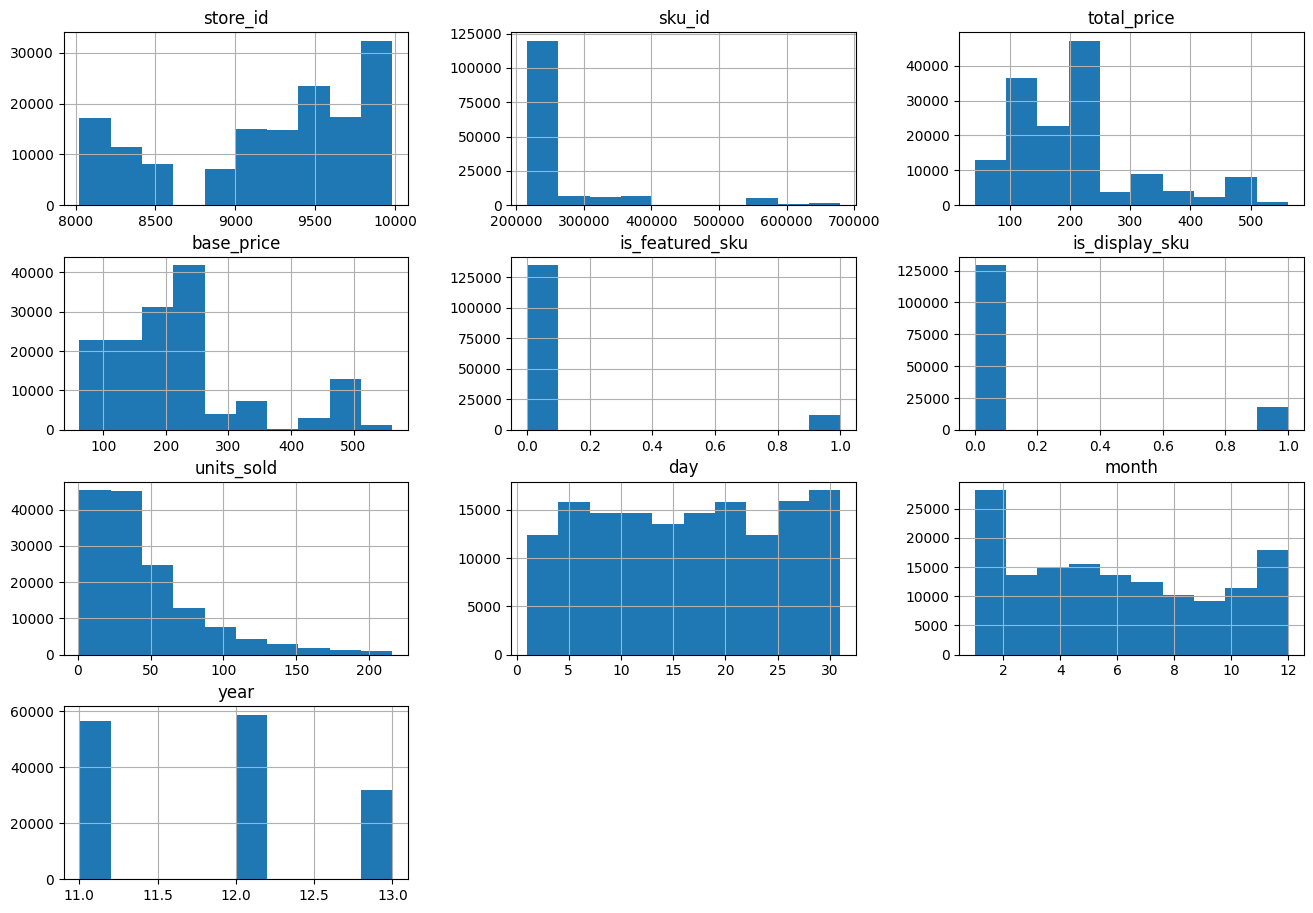

In [41]:
df.hist(figsize=(16,11))
plt.show()

Removed top 2% units_sold values to eliminate outliers and improve model stability.

In [11]:
df = df[df['units_sold'] < df['units_sold'].quantile(0.98)]

<Axes: >

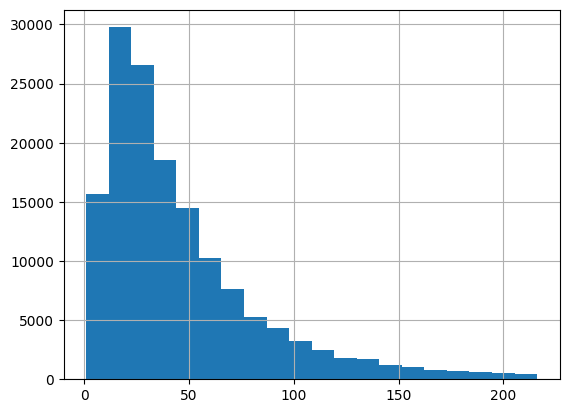

In [12]:
df['units_sold'].hist(bins=20)

In [13]:
df[['day', 'month', 'year']] = df['week'].str.split('/', expand=True)

In [14]:
df.drop(['record_ID', 'week'], axis=1, inplace=True)

In [15]:
df[['day', 'month', 'year']] = df[['day', 'month', 'year']].apply(pd.to_numeric)

In [16]:
df.dtypes

,0
store_id,int64
sku_id,int64
total_price,float64
base_price,float64
is_featured_sku,int64
is_display_sku,int64
units_sold,int64
day,int64
month,int64
year,int64


In [17]:
X = df.drop(columns='units_sold', axis=1)
y = df['units_sold']

In [18]:
X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=42)

In [19]:
models = {
    'LR': LinearRegression(),
    'DT': DecisionTreeRegressor(),
    'FR': RandomForestRegressor(),
    'XGB': XGBRegressor(eta=0.6, eval_metric="rmse"),
    'GBR': GradientBoostingRegressor(learning_rate=0.001),
}
rmse_scores = dict()

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

def adjusted_r2_score(y_true, y_pred, X):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = X.shape[1]
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = round(np.sqrt(mean_squared_error(y_val, y_pred)), 2)
    adj_r2 = round(adjusted_r2_score(y_val, y_pred, X_val), 4)
    metrics[name] = {"RMSE": rmse, "Adjusted R²": adj_r2}

# Display metrics as a table
import pandas as pd
metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

      RMSE  Adjusted R²
LR   32.92       0.2493
DT   23.86       0.6055
FR   17.28       0.7932
XGB  6.08       0.9209
GBR  37.03       0.0497


Testing the Voting Regressor and evaluating the performance.

In [24]:
from sklearn.ensemble import VotingRegressor

voting_model = VotingRegressor([
    ('rf', RandomForestRegressor(random_state=42)),
    ('xgb', XGBRegressor(eta=0.6, eval_metric="rmse", random_state=42)),
    ('gb', GradientBoostingRegressor(learning_rate=0.001, random_state=42))
])

voting_model.fit(X_train, y_train)
y_pred = voting_model.predict(X_val)

In [30]:
print(f"Voting Regressor → RMSE: {round(np.sqrt(mean_squared_error(y_val, y_pred)), 2)} | Adjusted R²: {round(adjusted_r2_score(y_val, y_pred, X_val), 4)}")

Voting Regressor → RMSE: 19.59 | Adjusted R²: 0.734


Based on the lowest RMSE and highest Adjusted R², XGBRegressor (XGB) outperforms all other models.
Although the Voting Regressor gives a competitive performance, it slightly underperforms compared to XGB alone, indicating that XGB captures the trend best on its own.

In [31]:
y_pred_xgb = models["XGB"].predict(X_val)

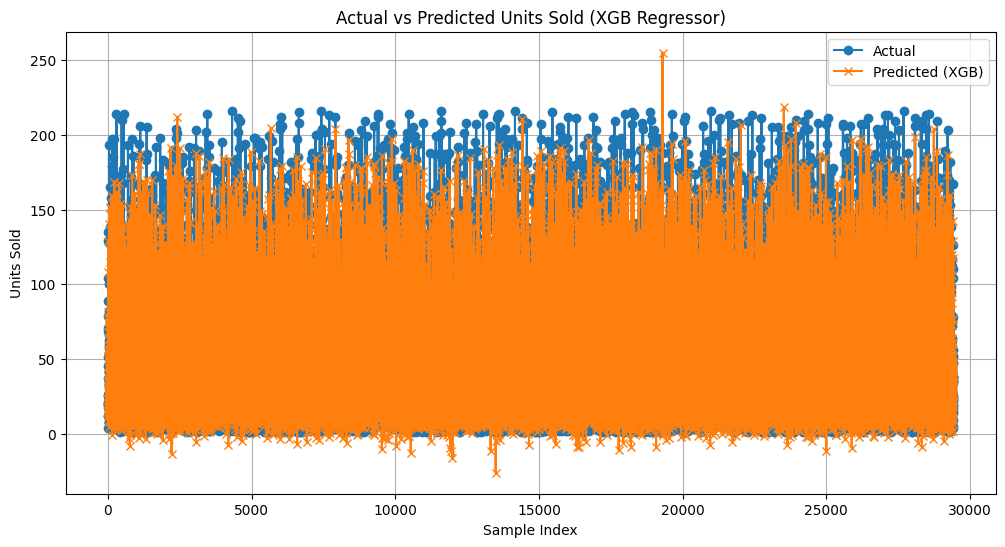

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_val)), y_val.values, label='Actual', marker='o')
plt.plot(range(len(y_pred_xgb)), y_pred_xgb, label='Predicted (XGB)', marker='x')
plt.title('Actual vs Predicted Units Sold (XGB Regressor)')
plt.xlabel('Sample Index')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()

Sample Prediction Comparison – XGBoost Regressor

In [42]:
# Select a few sample inputs
sample_inputs = X_val.iloc[:5]
real_outputs = y_val.iloc[:5]

# Predict using XGB Regressor
xgb_model = models["XGB"]  # Assuming XGB was saved in the 'models' dict
sample_preds_xgb = xgb_model.predict(sample_inputs)

# Create a DataFrame to compare actual vs predicted
result_df_xgb = pd.DataFrame({
    'Sample Index': sample_inputs.index,
    'Actual Units Sold': real_outputs.values,
    'Predicted Units Sold (XGB)': sample_preds_xgb.round(2)
})

print("Actual vs Predicted Units Sold (XGB - Sample Inputs):")
print(result_df_xgb.to_string(index=False))

Actual vs Predicted Units Sold (XGB - Sample Inputs):
 Sample Index  Actual Units Sold  Predicted Units Sold (XGB)
        45619                 12                   15.540001
        73601                 45                   42.070000
        96439                 20                   24.150000
       135612                 20                   19.930000
       138962                 79                   76.349998


Simulated Future Forecast – XGBoost Regressor

*   Visualizing predicted unit sales for the last 10 validation inputs as a proxy
for future demand.

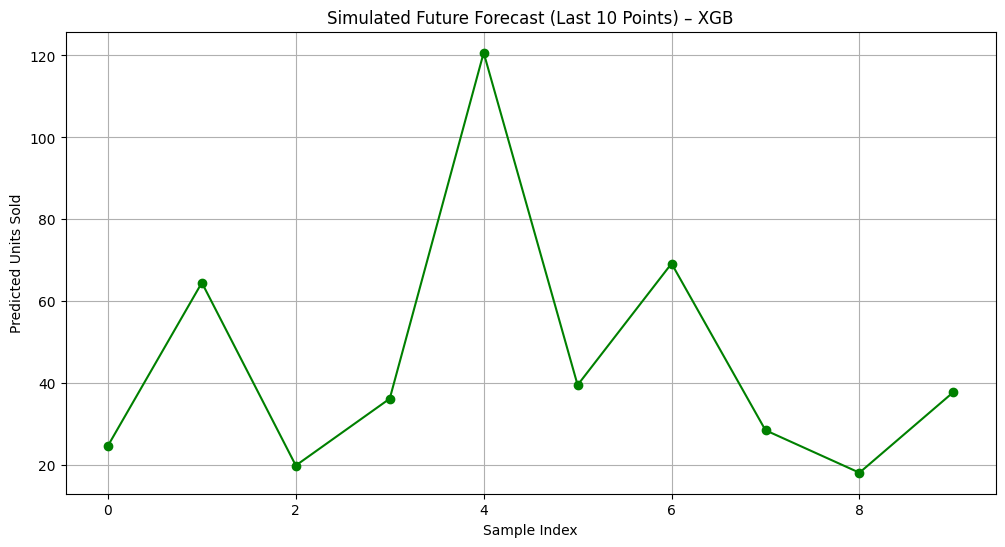

In [40]:
# Use last few samples from validation as future proxy
future_input = X_val.tail(10)

# Predict using optimized XGB model
future_preds = xgb_model.predict(future_input)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(range(len(future_preds)), future_preds, marker='o', linestyle='-', color='green')
plt.title('Simulated Future Forecast (Last 10 Points) – XGB')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Units Sold')
plt.grid(True)
plt.show()